In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
dataset = pd.read_csv("dataset/diabetes.csv")

# Exploratory Data Analysis

In [63]:
dataset.columns[dataset.isnull().any()]

Index([], dtype='object')

In [64]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [65]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [66]:
dataset.shape

(768, 9)

In [67]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Feature Selection with the help of Correlation

In [68]:
# No index column to drop in this dataset — Pima dataset is already clean
correlations = dataset.corr()['Outcome'].abs().sort_values(ascending=False)

In [69]:
# printing the top features (excluding Outcome itself)
top_features = correlations[1:6]
print("Top 5 Correlated Features:")
print(top_features)

Top 5 Correlated Features:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_25248\1563374733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


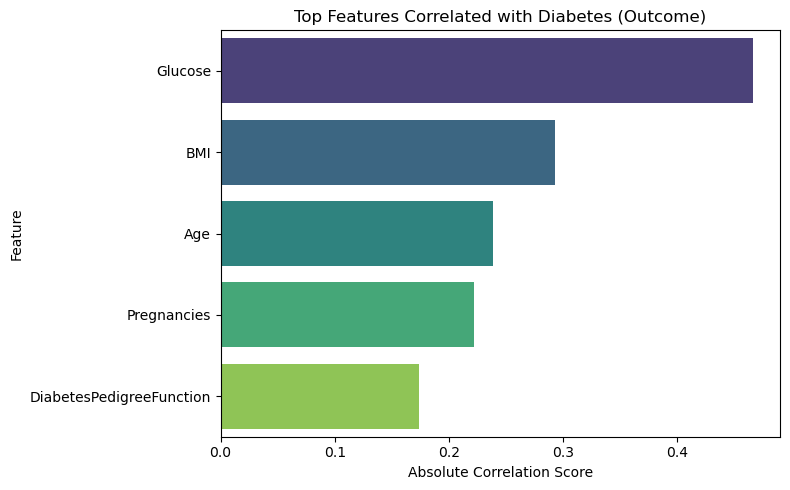

In [70]:
# visualizing 
plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top Features Correlated with Diabetes (Outcome)')
plt.xlabel('Absolute Correlation Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Neural Network Matrix Implementation

In [71]:
# Isolating Top 3 Features (Glucose, BMI, Age are the strongest predictors)
X = dataset[['Glucose', 'BMI', 'Age']].values 

In [72]:
# reshaping it into a 2D column vector instead of flat array
y = dataset['Outcome'].values.reshape(-1, 1)

In [73]:
print(y)

[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]


In [74]:
# Normalizing features using Min-Max scaling so values are between 0 and 1
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

print(f"Shape of Input Matrix X: {X.shape}")
print(f"Shape of Target Matrix y: {y.shape}")

Shape of Input Matrix X: (768, 3)
Shape of Target Matrix y: (768, 1)


# Neural Network Initialization

In [75]:
# Defining the network architecture ( 3 → 3 → 1)
input_nodes = 3
hidden_nodes = 3
output_nodes = 1

# Setting the random seed
np.random.seed(42)

In [76]:
# Initializing weight matrices
# Weights between Input Layer and Hidden Layer (3x3 matrix)
W1 = np.random.randn(input_nodes, hidden_nodes)

# Weights between Hidden Layer and Output Layer (3x1 matrix)
W2 = np.random.randn(hidden_nodes, output_nodes)

In [77]:
# Defining the activation function and its derivative (Sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):  # gives rate of change of sigmoid function
    return x * (1 - x)

In [78]:
print("Initial Weights W1 (Input to Hidden):\n", W1)
print("\nInitial Weights W2 (Hidden to Output):\n", W2)

Initial Weights W1 (Input to Hidden):
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]]

Initial Weights W2 (Hidden to Output):
 [[ 0.54256004]
 [-0.46341769]
 [-0.46572975]]


# Forward Pass & Backpropagation

In [79]:
learning_rate = 50 # Increased learning rate for faster convergence in this small dataset
epochs = 2

for epoch in range(epochs):
    # Forward pass

    # Calculate input to the hidden layer (Dot product of Input X and Weight 1)
    hidden_layer_input = np.dot(X, W1)

    # Apply activation function
    hidden_layer_output = sigmoid(hidden_layer_input)

    # Calculate input to the output layer (Dot product of Hidden Output and Weight 2)
    output_layer_input = np.dot(hidden_layer_output, W2)

    # Apply activation function to get our final prediction
    predicted_output = sigmoid(output_layer_input)

    # Errors
    # How far off is the prediction from the actual target?
    error = y - predicted_output

    # Backpropagation
    # Calculate the gradient for the output layer
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    # Calculate the error contribution of the hidden layer using matrix transposition (W2.T)
    error_hidden_layer = d_predicted_output.dot(W2.T)

    # Calculate the gradient for the hidden layer
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # Updating weights

    # Total number of patient samples
    m = X.shape[0]

    # Update W2 using the transposed hidden layer output
    W2 += hidden_layer_output.T.dot(d_predicted_output) * (learning_rate / m)

    # Update W1 using the transposed original input matrix
    W1 += X.T.dot(d_hidden_layer) * (learning_rate / m)

    # Print the error to see the network learning
    print(f"Iteration {epoch + 1} - Mean Absolute Error: {np.mean(np.abs(error)):.5f}")


print("\nVisualizing Result of Second Iteration ")
print("\nUpdated Weights W1 (Input to Hidden):\n", W1)
print("\nUpdated Weights W2 (Hidden to Output):\n", W2)

Iteration 1 - Mean Absolute Error: 0.49340
Iteration 2 - Mean Absolute Error: 0.39084

Visualizing Result of Second Iteration 

Updated Weights W1 (Input to Hidden):
 [[ 0.33292495 -0.35354281  0.42037742]
 [ 1.38841496 -0.36694113 -0.37603445]
 [ 1.53760001  0.66399391 -0.57915308]]

Updated Weights W2 (Hidden to Output):
 [[ 0.3123638 ]
 [-0.67237822]
 [-0.70164425]]


In [ ]:
# --- Before Training (reset weights using same seed) ---
np.random.seed(42)
W1_initial = np.random.randn(input_nodes, hidden_nodes)
W2_initial = np.random.randn(hidden_nodes, output_nodes)

# Forward pass with INITIAL weights
old_hidden = sigmoid(np.dot(X, W1_initial))
old_prediction = sigmoid(np.dot(old_hidden, W2_initial))
old_mae = np.mean(np.abs(y - old_prediction))
old_accuracy = np.mean((np.round(old_prediction) == y).astype(float)) * 100

# Forward pass with UPDATED weights (W1, W2 after training loop above)
new_hidden = sigmoid(np.dot(X, W1))
new_prediction = sigmoid(np.dot(new_hidden, W2))
new_mae = np.mean(np.abs(y - new_prediction))
new_accuracy = np.mean((np.round(new_prediction) == y).astype(float)) * 100

print("--- FINAL RESULT ---")
print(f"Old MAE:      {old_mae:.5f}   |   New MAE:      {new_mae:.5f}")
print(f"Old Accuracy: {old_accuracy:.2f}%  |   New Accuracy: {new_accuracy:.2f}%")
print()
print('If successful, New MAE should be LOWER and New Accuracy should be HIGHER!')

--- FINAL RESULT ---
Old MAE:      0.49340   |   New MAE:      0.46766
Old Accuracy: 64.84%  |   New Accuracy: 65.10%

If successful, New MAE should be LOWER and New Accuracy should be HIGHER!
